In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("Trainig Images Shape:",)
print(x_train.shape)
print("Testing Images Shape:",)
print(x_test.shape)
print("Trainig Labels Shape:",)
print(y_train.shape)
print("Testing Labels Shape:",)
print(y_test.shape)

Trainig Images Shape:
(60000, 28, 28)
Testing Images Shape:
(10000, 28, 28)
Trainig Labels Shape:
(60000,)
Testing Labels Shape:
(10000,)


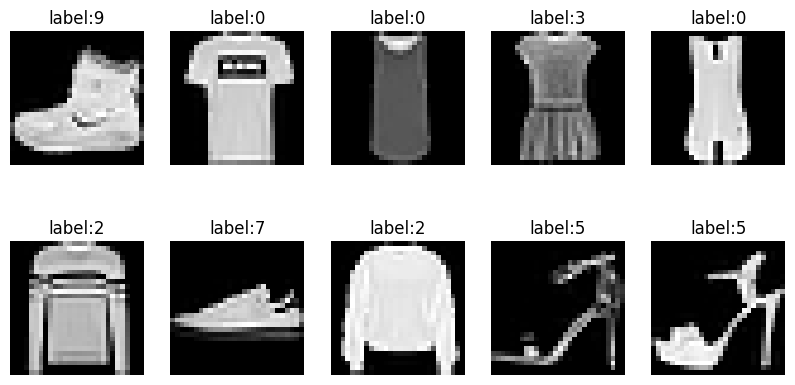

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(f"label:{y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
x_train=x_train/255.0
x_test=x_test/225.0

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7581 - loss: 0.6698 - val_accuracy: 0.8353 - val_loss: 0.4523
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.8431 - loss: 0.4421 - val_accuracy: 0.8617 - val_loss: 0.3758
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8632 - loss: 0.3781 - val_accuracy: 0.8726 - val_loss: 0.3531
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.8772 - loss: 0.3388 - val_accuracy: 0.8720 - val_loss: 0.3411
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.8877 - loss: 0.3075 - val_accuracy: 0.8805 - val_loss: 0.3171
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - accuracy: 0.8983 - loss: 0.2815 - val_accuracy: 0.8823 - val_loss: 0.3099
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9033 - loss: 0.2658 - val_accuracy: 0.8922 - val_loss: 0.3004
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9098 -

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print("Test Loss",test_loss)
print("Test Accuracy",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8794 - loss: 0.3706
Test Loss 0.3706141412258148
Test Accuracy 0.8794000148773193


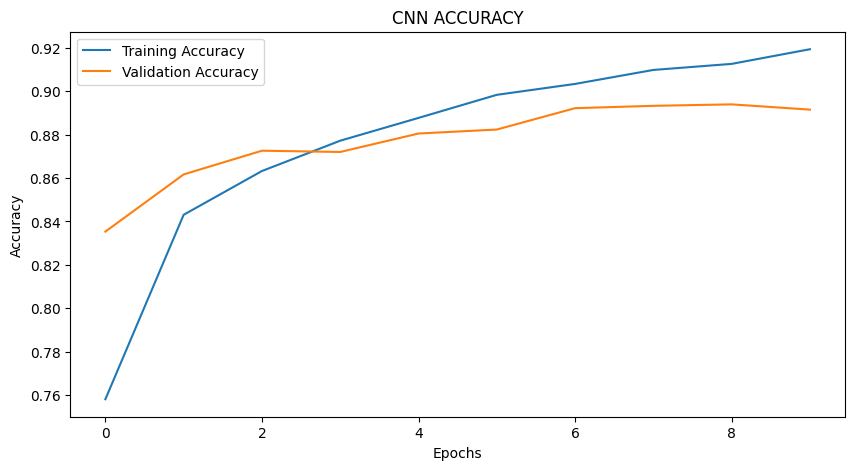

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN ACCURACY')
plt.legend()
plt.show()


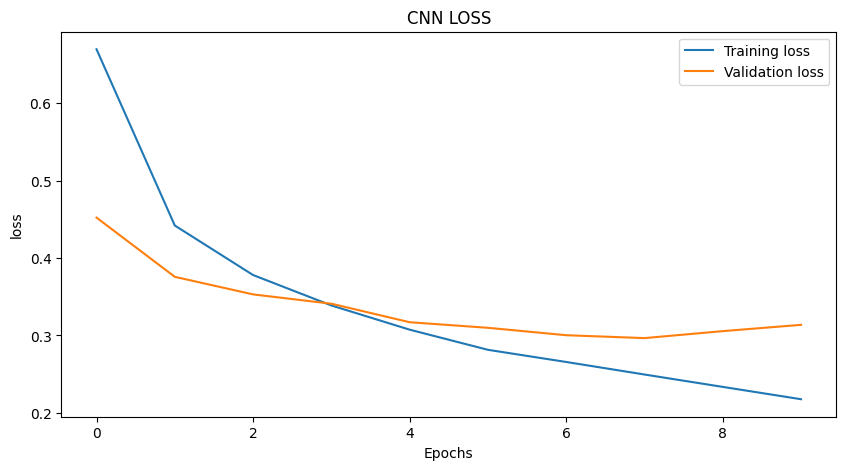

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('CNN LOSS')
plt.legend()
plt.show()

In [ ]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


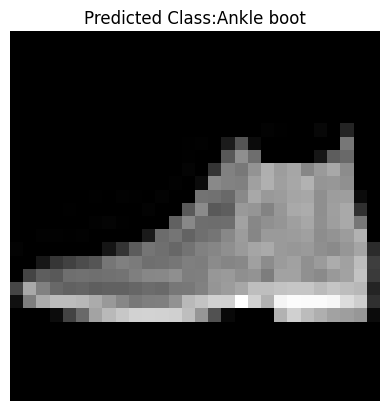

In [ ]:
sample=x_test[0]
prediction=model.predict(sample.reshape(1,28,28,1))
predicted_class=np.argmax(prediction)
predicted_class_name=class_names[predicted_class]
plt.imshow(sample.reshape(28,28),cmap='gray')
plt.title(f"Predicted Class:{predicted_class_name}")
plt.axis('off')
plt.show()

Saving dress.webp to dress (2).webp


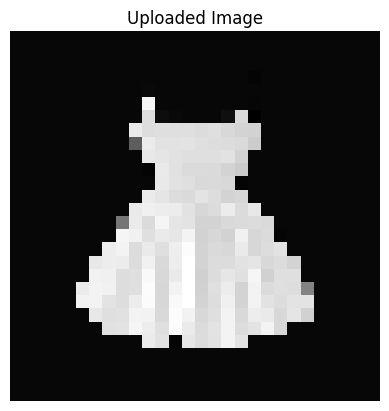

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Class:Dress
confidence score: 66.51424 %


In [ ]:

from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
uploaded=files.upload()
img_path=list(uploaded.keys())[0]
img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(28,28))
img=255 - img
img=img/255.0

#display
plt.imshow(img,cmap='gray')
plt.title('Uploaded Image')
plt.axis('off')
plt.show()
#reshape
img=img.reshape(1,28,28,1)
#predict
prediction=model.predict(img)
predicted_class=np.argmax(prediction)
predicted_class_name=class_names[predicted_class]
print(f"Predicted Class:{predicted_class_name}")
#confidence code
print(f"confidence score:",np.max(prediction)*100,"%")